### Buid A basic chat bot with langraph (Graph API)

In [37]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages #recducer


In [38]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    
    messages: Annotated[list, add_messages]

graph_builder =StateGraph(State)

In [39]:
graph_builder

In [40]:
import os 
from dotenv import load_dotenv
load_dotenv()
#os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


True

In [41]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-20b")

In [42]:
# we also do like _>
# llm = init_chat_model("groq:llama-3.1-8b-instant")

In [43]:
# Node functionality 
def chatbot(state):
    return {"messages":[llm.invoke(state["messages"])]}


In [44]:
graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)

## Adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph = graph_builder.compile()

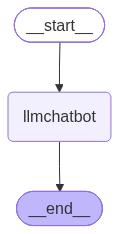

In [45]:
## visulization
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [46]:
responce=graph.invoke({"messages":"Hi how are you"})

In [47]:
responce["messages"][-1]

AIMessage(content="Hello! I'm just a bundle of code, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?", additional_kwargs={'reasoning_content': 'User says "Hi how are you". Simple greeting. Should respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 75, 'total_tokens': 131, 'completion_time': 0.075945283, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.003511704, 'prompt_tokens_details': None, 'queue_time': 0.191633567, 'total_time': 0.079456987}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_334cc21c60', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a06c5f-84cf-7c62-a743-0cd1fda9cd76-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 75, 'output_tokens': 56, 'total_tokens': 131, 'output_token_details': {'reasoning': 16}})

In [48]:
for event in graph.stream({"messages":"hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)


Hi there! I'm doing great—thanks for asking. How can I help you today?


### chat with Tools


In [49]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'What is LangGraph? | IBM',
   'url': 'https://www.ibm.com/think/topics/langgraph',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norweg

In [50]:
## custom function 
def multply(a:int,b:int)->int:
    """MUTILPY a and  b 
    Args:
    a (int) : first int
    b (int) : second int
        int: output int 
    """
    return a*b


In [51]:
tools = [tool,multply]

In [52]:
llm_with_tool= llm.bind_tools(tools)

In [53]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F63399AAD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F63399AC10>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and

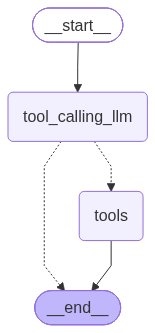

In [54]:
### let's create  state graph 
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node defination
def tool_calling_llm(state):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}
# graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)
## complie the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [55]:
responce=graph.invoke({"messages":"Hi how are you"})

In [56]:
responce["messages"][-1].content

'Hi! I’m doing great—thanks for asking. How can I help you today?'

In [57]:
for event in graph.stream({"messages":"hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content )

Hi! I'm doing great—thanks for asking. How can I help you today?


In [58]:
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi how are you
================================== Ai Message ==================================

Hi! I’m doing great—thanks for asking. How can I help you today?


In [59]:
responce = graph.invoke({"messages":"what is 2 multiplied by 7"})
for m in responce["messages"]:
    m.pretty_print()


================================ Human Message =================================

what is 2 multiplied by 7
================================== Ai Message ==================================
Tool Calls:
  multply (fc_c1910455-b00b-40da-bb79-3e9ada5b8c05)
 Call ID: fc_c1910455-b00b-40da-bb79-3e9ada5b8c05
  Args:
    a: 2
    b: 7
================================= Tool Message =================================
Name: multply

14


In [60]:
responce = graph.invoke({"messages":"what is 2 multiplred by 7 and then multilped by 5"})
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2 multiplred by 7 and then multilped by 5
================================== Ai Message ==================================

\(2 \times 7 = 14\)  
\(14 \times 5 = 70\)  

So the result is **70**.


In [61]:
responce = graph.invoke({"messages":"give me the recent ai news  and then multiply 5 * 20"})
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me the recent ai news  and then multiply 5 * 20
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_c02eac00-5092-49d6-b471-81e950aa398e)
 Call ID: fc_c02eac00-5092-49d6-b471-81e950aa398e
  Args:
    query: recent AI news
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/google-ai-updates-august-2026", "title": "The latest AI news we announced in August 2026", "content": "In August, we continued advancing AI responsibly — making it faster, more accessible, and truly practical for everyone, from software developers and students to creatives and scientists. We’re bringing intelligence directly to w

In [62]:
## so what  tool's answer goes nack to llm and then dicission is taken by llm 
# - Act -> Observe -> Reason

## ReAct agent architecture

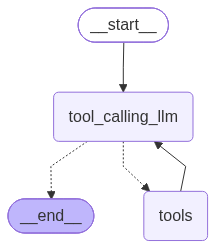

In [63]:
### let's create  state graph 
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node defination
def tool_calling_llm(state):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}
# graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")
## complie the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [64]:
## Now this will answer correctly 
responce = graph.invoke({"messages":"give me the recent ai news  and then multiply 5 * 20"})
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me the recent ai news  and then multiply 5 * 20
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_5877ff13-4ac3-4ff6-a76b-2c99120fc82c)
 Call ID: fc_5877ff13-4ac3-4ff6-a76b-2c99120fc82c
  Args:
    query: recent AI news
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/google-ai-updates-august-2026", "title": "The latest AI news we announced in August 2026", "content": "In August, we continued advancing AI responsibly — making it faster, more accessible, and truly practical for everyone, from software developers and students to creatives and scientists. We’re bringing intelligence directly to w

## Adding Memoery in Agentic Graph 

In [65]:
responce = graph.invoke({"messages":"hello my name is vishal"})
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

hello my name is vishal
================================== Ai Message ==================================

Hello Vishal! 👋 How can I assist you today?


In [66]:
responce = graph.invoke({"messages":"what is my name ?"})
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is my name ?
================================== Ai Message ==================================

I don’t have that information. If you’d like me to remember it for future conversations, just let me know!


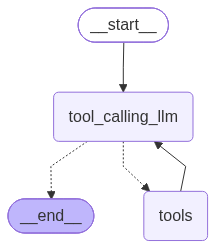

In [67]:
### let's create  state graph 
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node defination
def tool_calling_llm(state):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}
# graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")
## complie the graph
graph=builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [68]:
config = {"configurable":{"thread_id":"1"}}
responce = graph.invoke({"messages":"hi my name is vishal "},config=config)
responce

{'messages': [HumanMessage(content='hi my name is vishal ', additional_kwargs={}, response_metadata={}, id='f31376a0-43b5-4606-95f1-1cdce138e09a'),
  AIMessage(content='Hello Vishal! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "hi my name is vishal". We can greet. Possibly ask what can help.'}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 375, 'total_tokens': 425, 'completion_time': 0.054229103, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.018508686, 'prompt_tokens_details': None, 'queue_time': 0.337193827, 'total_time': 0.072737789}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_7d448090ba', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a06c5f-bb24-7571-96ac-1f97a08bff43-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 375, 'output_tokens': 50, 'total_tokens': 

In [69]:
responce["messages"][-1].content

'Hello Vishal! 👋 How can I help you today?'

In [70]:
responce = graph.invoke({"messages":"what is my name..?"},config=config)
responce



{'messages': [HumanMessage(content='hi my name is vishal ', additional_kwargs={}, response_metadata={}, id='f31376a0-43b5-4606-95f1-1cdce138e09a'),
  AIMessage(content='Hello Vishal! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "hi my name is vishal". We can greet. Possibly ask what can help.'}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 375, 'total_tokens': 425, 'completion_time': 0.054229103, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.018508686, 'prompt_tokens_details': None, 'queue_time': 0.337193827, 'total_time': 0.072737789}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_7d448090ba', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a06c5f-bb24-7571-96ac-1f97a08bff43-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 375, 'output_tokens': 50, 'total_tokens': 

In [71]:
responce["messages"][-1].content

'Your name is Vishal. If there’s anything else you’d like to know or discuss, just let me know!'

# Streaming 

In [72]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()


In [79]:
def superBot(State: State):
    return {"messages": [llm.invoke(State["messages"])]}

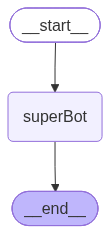

In [80]:
graph= StateGraph(State)

## Node 
graph.add_node("superBot",superBot)

## Edges
graph.add_edge(START,"superBot")
graph.add_edge("superBot",END)

graph_builder = graph.compile(checkpointer=memory)

## Display 
from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [82]:
config = {"configurable":{"thread_id":"1"}}
responce = graph_builder.invoke({"messages":"hi name is vishal i like poetry"},config)

In [84]:
responce["messages"][-1].content

'Hey Vishal! 👋 It’s great to hear you’re into poetry. What would you like to do today?  \n- Want a quick poem I can write for you?  \n- Looking for some famous lines or poets to explore?  \n- Need help crafting your own verses?  \n\nJust let me know, and we’ll dive right in!'

## Streaming

**Methods:** `.stream()` and `.astream()`

- These methods are sync and async methods for streaming back results.

### Additional parameters in streaming modes for graph state

- **`values`**: This streams the full state of the graph after each node is called.
- **`updates`**: This streams updates to the state of the graph after each node is called.

In [88]:
config = {"configurable":{"thread_id":"3"}}

for chunk in graph_builder.stream({"messages":"hi my name is vishal i like poetries"},config,stream_mode="updates"):
    print(chunk)

{'superBot': {'messages': [AIMessage(content='Hey Vishal! 👋  \n\nIt’s always a pleasure to meet a fellow poetry fan.  \nHere’s a quick little poem just for you—feel free to tweak it or let me know what style you’d like next!\n\n> **Whispers in the Wind**  \n> \n>  The breeze carries words that never were spoken,  \n>  Threads of rhyme stitched into the sky.  \n>  In every gust, a stanza is woven,  \n>  And silence turns into a lullaby.  \n\nWhat kind of poems do you enjoy most? Classic sonnets, haiku, free‑verse, or something else? I’d love to hear your favorites or help you craft a new one!', additional_kwargs={'reasoning_content': "User says hi again. They mention name and like poetry. They likely want something. Could respond friendly, ask what they like. Provide a poem. Let's give a short poem."}, response_metadata={'token_usage': {'completion_tokens': 188, 'prompt_tokens': 294, 'total_tokens': 482, 'completion_time': 0.211293987, 'completion_tokens_details': {'reasoning_tokens': 3

In [89]:
for chunk in graph_builder.stream({"messsages":"hi my name is vishal i like poetries"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='hi my name is vishal i like poetries', additional_kwargs={}, response_metadata={}, id='ed6fe77e-b74d-464b-b46e-06e49aa017db'), AIMessage(content='Hello Vishal! 👋  \nIt’s great to meet a poetry lover. What kind of poems do you enjoy the most? Classic sonnets, free‑verse, haiku, or something else? If you’d like, I can share a short poem right now or even help you write one. Just let me know!', additional_kwargs={'reasoning_content': "We need to respond to user. They say hi, name Vishal, likes poetries. We should respond accordingly. Possibly ask about what kind of poetry they like, or share a poem. The instructions: we are ChatGPT. We should be friendly, maybe ask about preferences. Also we can provide a short poem. Let's produce a warm response."}, response_metadata={'token_usage': {'completion_tokens': 148, 'prompt_tokens': 83, 'total_tokens': 231, 'completion_time': 0.152684279, 'completion_tokens_details': {'reasoning_tokens': 73}, 'prompt_time': 0

In [90]:
config = {"configurable":{"thread_id":"4"}}

for chunk in graph_builder.stream({"messages":"hi my name is vishal i like poetries"},config,stream_mode="updates"):
    print(chunk)

{'superBot': {'messages': [AIMessage(content='Hello Vishal! 🎉 It’s wonderful to meet a poetry enthusiast. What kind of poems or poets do you enjoy most? Do you prefer classic sonnets, modern free‑verse, or perhaps something like haiku or slam poetry? I’d love to hear what sparks your imagination, and I can even share a fresh piece or help you craft your own. Let’s dive into the world of words together!', additional_kwargs={'reasoning_content': 'User says hi, name, likes poetry. Should respond. Probably ask more.'}, response_metadata={'token_usage': {'completion_tokens': 109, 'prompt_tokens': 172, 'total_tokens': 281, 'completion_time': 0.161822902, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.011363525, 'prompt_tokens_details': None, 'queue_time': 0.241329767, 'total_time': 0.173186427}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_66891002f6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, 

In [91]:
for chunk in graph_builder.stream({"messages":"i also like sketching"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='hi my name is vishal i like poetries', additional_kwargs={}, response_metadata={}, id='971df3ac-160f-4ebd-971f-4701ef73bfb1'), AIMessage(content='Hello Vishal! 🌟 It’s great to meet someone who loves poetry. Do you have any favorite poets or styles (like haiku, sonnets, free verse, etc.)? I’d love to hear what moves you, and I can share a short poem or even help you write one if you’re up for it!', additional_kwargs={'reasoning_content': 'We need to respond. The user says "hi my name is vishal i like poetries". They are greeting and stating they like poetry. We should respond politely, maybe ask about their favorite poets, or share a short poem. The user might want poetry. Let\'s respond friendly, ask about preferences, maybe share a short poem.'}, response_metadata={'token_usage': {'completion_tokens': 146, 'prompt_tokens': 83, 'total_tokens': 229, 'completion_time': 0.172152884, 'completion_tokens_details': {'reasoning_tokens': 70}, 'prompt_time': 0

In [95]:
config = {"configurable":{"thread_id":"5"}}

async for  event in graph_builder.astream_events({"messages":"hi my name is vishal i like poetries"},config,version="v2",):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'hi my name is vishal i like poetries'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a06c95-ba83-7fc0-ae91-2bb12655874c', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='hi my name is vishal i like poetries', additional_kwargs={}, response_metadata={}, id='a166f644-a27d-48bf-aa3a-204dffd7bc91'), AIMessage(content='Hi Vishal! 👋  \nIt’s great to meet a poetry lover. What’s your favorite type of poem—haiku, sonnets, free‑verse, or maybe something else? If you’d like, I can share a short poem or even create a personalized one for you. Let me know what you’re in the mood for!', additional_kwargs={'reasoning_content': 'The user says: "hi my name is vishal i like poetries". The user is greeting and telling us they like poetry. We should respond in a friendly manner, maybe ask about their favorite poet or style. They di